# Dutch / EU Licence Plate Detection
Step-by-step object detection on images inside the `data-images` folder using **YOLOv11** for plate localisation and **EasyOCR** for text recognition.

## 1. Import Required Libraries

In [1]:
import re
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure Detection Settings

In [2]:
# ── Settings ──────────────────────────────────────────────────────────────────
IMAGE_FOLDER     = Path("data-images")          # folder containing test images
CONF_THRESHOLD   = 0.30                          # YOLO minimum detection confidence
PADDING          = 8                             # pixels to expand each crop side
YOLO_MODEL_NAME  = "license-plate-finetune-v1n.onnx"
SUPPORTED_EXT    = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
OUTPUT_CSV       = Path("detection_results.csv") # summary export path

# ── OCR params (tuned for close-up plate crops) ───────────────────────────────
BEST_PARAMS = dict(
    text_threshold=0.6,
    low_text=0.4,
    mag_ratio=1.8,
    link_threshold=0.5,
    width_ths=0.7,
    decoder='beamsearch',
    beamWidth=5,
    allowlist=None,
    paragraph=False,
)

print(f"Image folder : {IMAGE_FOLDER.resolve()}")
print(f"Conf threshold: {CONF_THRESHOLD}")
print(f"YOLO model   : {YOLO_MODEL_NAME}")
print(f"OCR params   : {BEST_PARAMS}")

Image folder : C:\Users\krist\Documents\GitHub\Object-Detection-Research\data-images
Conf threshold: 0.3
YOLO model   : license-plate-finetune-v1n.onnx
OCR params   : {'text_threshold': 0.6, 'low_text': 0.4, 'mag_ratio': 1.8, 'link_threshold': 0.5, 'width_ths': 0.7, 'decoder': 'beamsearch', 'beamWidth': 5, 'allowlist': None, 'paragraph': False}


## 3. Load YOLO and OCR Models
The YOLO model is downloaded automatically from Hugging Face on first run. EasyOCR uses Dutch + English for NL plate recognition.

In [3]:
from ultralytics import YOLO

print("[1/2] Loading YOLO model …")
yolo_model = YOLO(YOLO_MODEL_NAME)
print("      YOLO ready.")


[1/2] Loading YOLO model …
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
      YOLO ready.


In [4]:
import easyocr

print("[2/2] Loading EasyOCR (nl + en) …")
ocr_reader = easyocr.Reader(["nl", "en"], gpu=False, verbose=False)
print("      EasyOCR ready.")

[2/2] Loading EasyOCR (nl + en) …
      EasyOCR ready.


## 4. Load Images from `data-images` Folder

In [5]:
if not IMAGE_FOLDER.is_dir():
    raise FileNotFoundError(f"Folder not found: {IMAGE_FOLDER.resolve()}")

image_files = sorted(
    p for p in IMAGE_FOLDER.iterdir()
    if p.suffix.lower() in SUPPORTED_EXT
)

print(f"Found {len(image_files)} image(s) in '{IMAGE_FOLDER}':")
for p in image_files:
    print(f"  • {p.name}")

Found 3 image(s) in 'data-images':
  • dsc0226.jpg
  • DSC_1939.JPG
  • nederland150.jpg


## 5. Run Detection on Each Image
For every image: run YOLO inference → crop detected boxes (with padding) → upscale crop → run EasyOCR → collect results.

In [6]:
def clean_plate_text(text: str) -> str:
    """Uppercase, strip non-alphanumerics."""
    return re.sub(r"[^A-Z0-9]", "", text.upper())


def run_detection(img_bgr: np.ndarray):
    """Return (detections list, annotated BGR image)."""
    h, w = img_bgr.shape[:2]
    results = yolo_model(img_bgr, conf=CONF_THRESHOLD, verbose=False)[0]

    detections = []
    annotated = img_bgr.copy()

    for box in results.boxes:
        det_conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        # Padded crop
        cx1 = max(0, x1 - PADDING)
        cy1 = max(0, y1 - PADDING)
        cx2 = min(w, x2 + PADDING)
        cy2 = min(h, y2 + PADDING)
        crop = img_bgr[cy1:cy2, cx1:cx2].copy()

        # Upscale for better OCR accuracy
        scale = max(1, 200 // max(crop.shape[:2]))
        if scale > 1:
            crop = cv2.resize(crop, None, fx=scale, fy=scale,
                              interpolation=cv2.INTER_CUBIC)

        ocr_results = ocr_reader.readtext(crop, **BEST_PARAMS)

        plate_text, ocr_conf = "", 0.0
        if ocr_results:
            best = max(ocr_results, key=lambda r: r[2])
            plate_text = clean_plate_text(best[1])
            ocr_conf = float(best[2])

        # Annotate image
        color = (0, 200, 60)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        label = f"{plate_text}  det:{det_conf:.0%}  ocr:{ocr_conf:.0%}"
        cv2.rectangle(annotated, (x1, y1 - 22), (x2, y1), color, -1)
        cv2.putText(annotated, label, (x1 + 4, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1, cv2.LINE_AA)

        detections.append({
            "plate_text":      plate_text,
            "detection_conf":  round(det_conf, 4),
            "ocr_conf":        round(ocr_conf, 4),
            "bbox":            [x1, y1, x2, y2],
            "crop_bgr":        img_bgr[cy1:cy2, cx1:cx2].copy(),
        })

    return detections, annotated


# ── Run over all images ────────────────────────────────────────────────────────
all_results = []   # list of dicts: {file, detections, annotated}

for img_path in image_files:
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"  [skip] Could not read {img_path.name}")
        continue

    detections, annotated = run_detection(img_bgr)
    all_results.append({
        "file":       img_path.name,
        "detections": detections,
        "annotated":  annotated,
    })
    print(f"  ✓ {img_path.name}  →  {len(detections)} plate(s) detected")

print(f"\nProcessed {len(all_results)} image(s).")

Loading license-plate-finetune-v1n.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider


c:\Users\krist\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  ✓ dsc0226.jpg  →  1 plate(s) detected
  ✓ DSC_1939.JPG  →  1 plate(s) detected
  ✓ nederland150.jpg  →  1 plate(s) detected

Processed 3 image(s).


## 6. Display Annotated Results
For each processed image the full annotated view is shown, followed by individual plate crops with their OCR text.

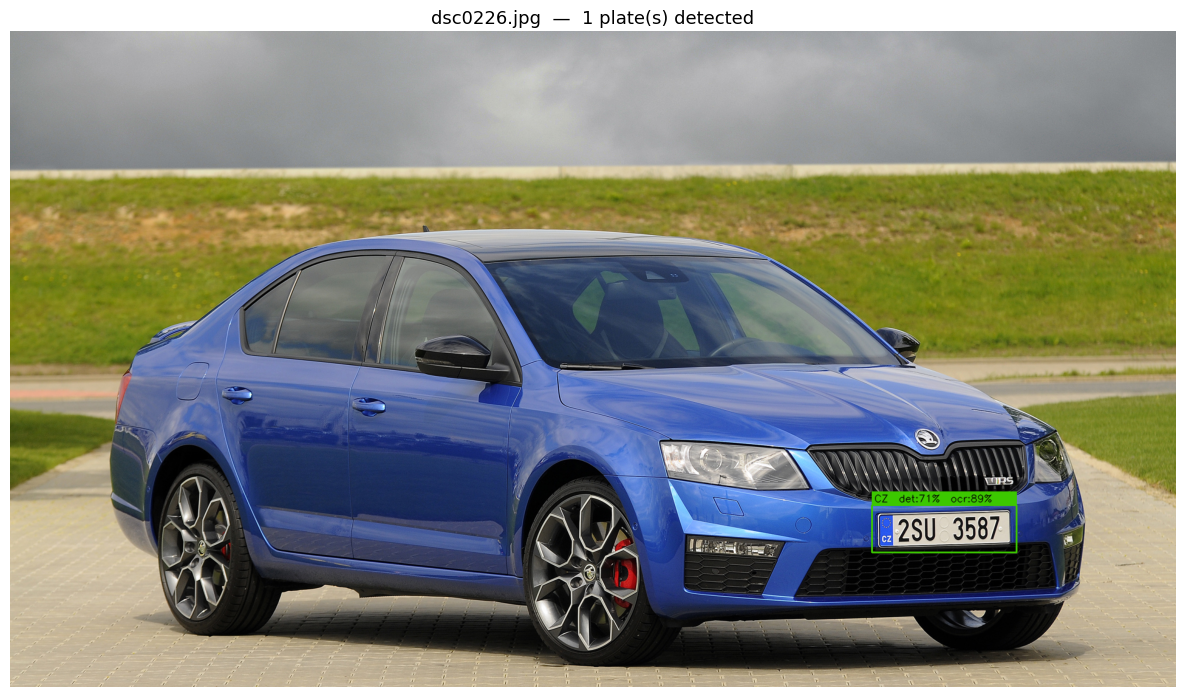

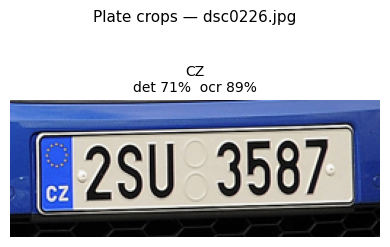

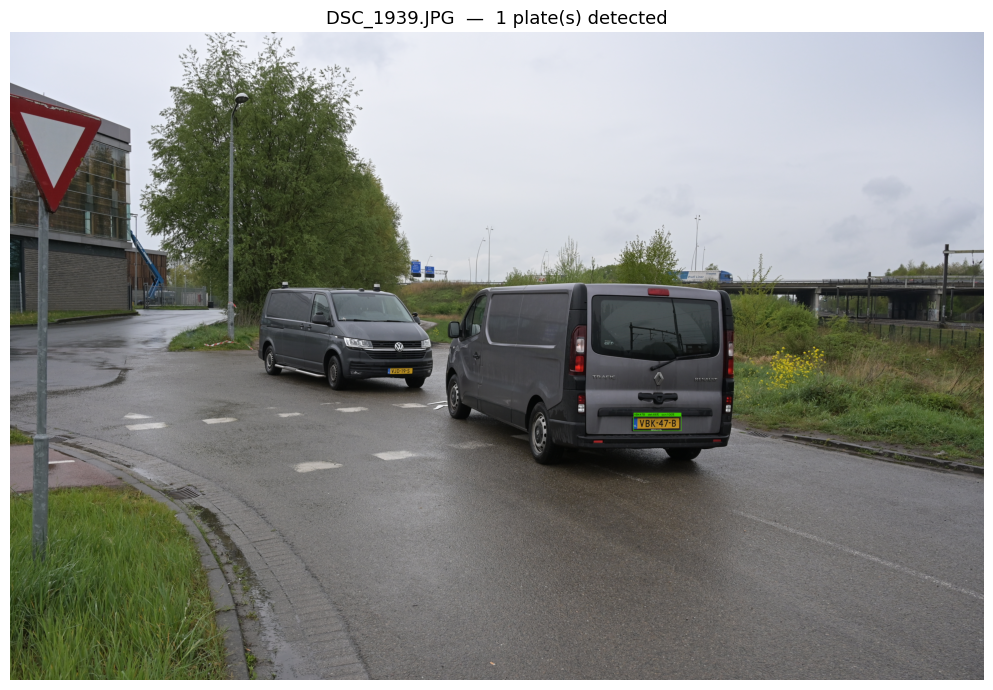

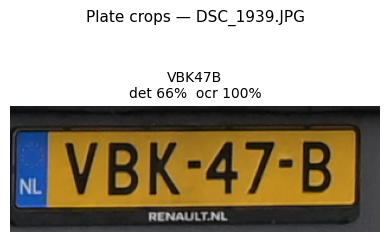

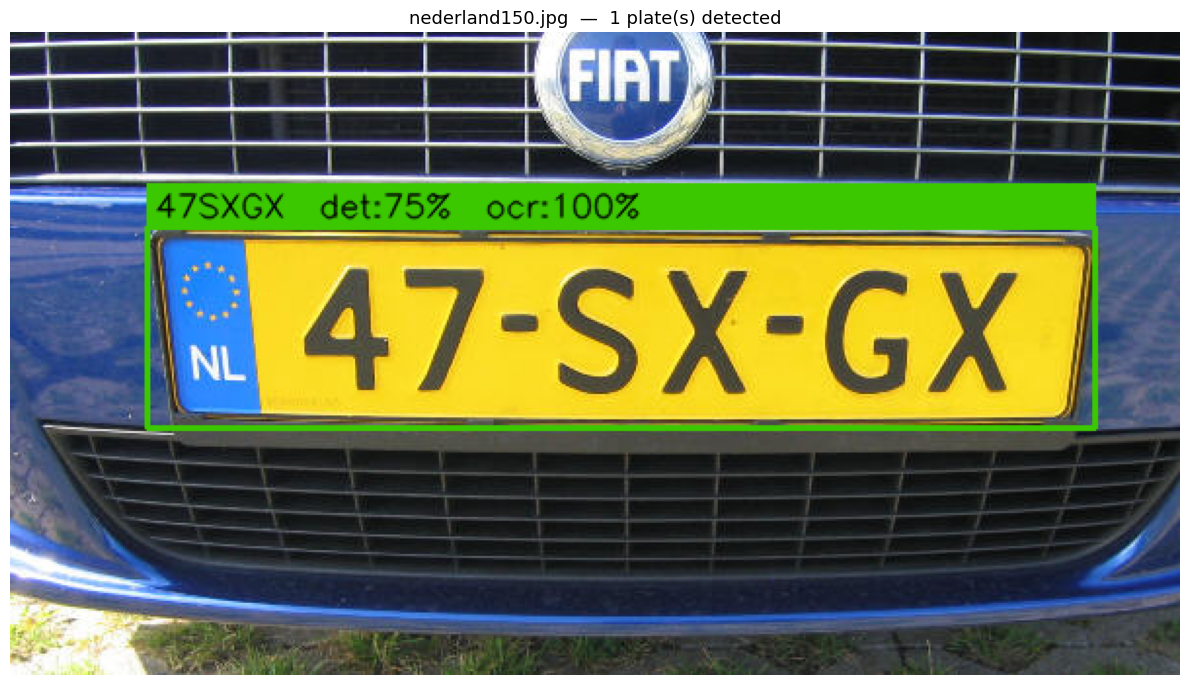

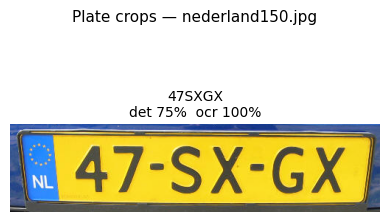

In [7]:
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


for result in all_results:
    fname      = result["file"]
    detections = result["detections"]
    annotated  = result["annotated"]

    # ── Full annotated image ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(bgr_to_rgb(annotated))
    ax.set_title(f"{fname}  —  {len(detections)} plate(s) detected", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # ── Individual plate crops ────────────────────────────────────────────
    if detections:
        n = len(detections)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
        if n == 1:
            axes = [axes]
        for ax, det in zip(axes, detections):
            ax.imshow(bgr_to_rgb(det["crop_bgr"]))
            ax.set_title(
                f"{det['plate_text'] or '(no text)'}\n"
                f"det {det['detection_conf']:.0%}  ocr {det['ocr_conf']:.0%}",
                fontsize=10
            )
            ax.axis("off")
        plt.suptitle(f"Plate crops — {fname}", fontsize=11)
        plt.tight_layout()
        plt.show()